GitHub Repository Data Analysis
Project Overview

This project collects repository data from the GitHub API, prepares and cleans the dataset using Pandas, stores the cleaned data in a SQLite database, and analyses the data using SQL and Python visualizations.

The project focuses on exploring repository popularity, programming languages, repository statistics, and repository creation trends over time.

-------------------------------------------------------------------------

Task 1: Data Collection & Preparation
1. Collecting Data from the GitHub API

Repository data is retrieved from the GitHub API using a search request. The API response is returned in JSON format and contains information about repositories such as their names, owners, programming languages, stars, forks, watchers, issues, creation dates, update dates, and licenses.

The collected JSON data is then converted into a Pandas DataFrame for further exploration and preparation.

In [102]:
import pandas as pd
import requests

In [103]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

In [104]:
response.status_code

200

In [105]:
data = response.json()
df = pd.DataFrame(data["items"])

2. Exploring the Dataset

The dataset is explored using Pandas to understand its structure, number of records, columns, and data types.

The following functions are used to inspect the dataset:

* df.head() to preview the first records.
* df.info() to inspect column names and data types.
* df.shape to determine the number of rows and columns.
* df.columns to identify the available columns.


In [106]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76049,2863,197056,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34252,2384,164137,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21954,11,89431,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,53,82494,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15612,24,74049,master,1.0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [108]:
df.shape

(100, 82)

In [109]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

3. Selecting Required Columns

Only the columns required for the analysis are retained. This reduces unnecessary data and makes the dataset easier to analyse.

Some values are originally stored inside nested JSON objects, such as the repository owner and license. These values are extracted and stored as separate columns.

In [110]:
df= df[[
"name", "owner" , "language" , "stargazers_count" , "forks_count" , "watchers_count" , "open_issues_count" , "created_at" , "updated_at" , "license"
]]

In [111]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197056,76049,197056,2863,2015-11-07T01:19:20Z,2026-08-16T12:51:32Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164137,34252,164137,2384,2018-10-29T13:56:00Z,2026-08-16T12:52:01Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T12:52:07Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82494,15266,82494,53,2018-08-21T11:20:39Z,2026-08-16T12:42:48Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74049,15612,74049,24,2014-07-15T19:11:19Z,2026-08-16T12:48:59Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [112]:
for i in range(len(df)):
    df.loc[i, "owner"] = df.loc[i, "owner"]["login"]

In [113]:
for i in range(len(df)):
    if isinstance(df.loc[i, "license"], dict):
        df.loc[i, "license"] = df.loc[i, "license"]["name"]

In [114]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07T01:19:20Z,2026-08-16T12:51:32Z,Apache License 2.0
1,transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29T13:56:00Z,2026-08-16T12:52:01Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T12:52:07Z,MIT License
3,funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21T11:20:39Z,2026-08-16T12:42:48Z,None
4,awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15T19:11:19Z,2026-08-16T12:48:59Z,Other


4. Handling Missing Values and Duplicate Records

The dataset is checked for missing values and duplicate records.

Missing values in the selected columns are handled using an appropriate replacement value, while duplicate records are identified and removed to ensure that each repository appears only once in the cleaned dataset.

This step improves the quality and consistency of the dataset before storing it in the database.

In [115]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [116]:
df['language']=df['language'].fillna("unknown")

In [117]:
df['license']=df['license'].fillna("Other")

In [118]:
df.head(20)

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07T01:19:20Z,2026-08-16T12:51:32Z,Apache License 2.0
1,transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29T13:56:00Z,2026-08-16T12:52:01Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T12:52:07Z,MIT License
3,funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21T11:20:39Z,2026-08-16T12:42:48Z,Other
4,awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15T19:11:19Z,2026-08-16T12:48:59Z,Other
5,scikit-learn,scikit-learn,Python,66960,27291,66960,2128,2010-08-17T09:43:38Z,2026-08-16T12:48:36Z,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,gradio-app,Python,43368,3574,43368,184,2018-12-19T08:24:04Z,2026-08-16T04:08:17Z,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,unknown,36299,7434,36299,67,2021-01-02T12:08:37Z,2026-08-16T12:55:58Z,Other
8,C-Plus-Plus,TheAlgorithms,C++,34582,7852,34582,32,2016-07-16T10:19:45Z,2026-08-16T12:46:04Z,MIT License
9,netron,lutzroeder,JavaScript,33358,3172,33358,16,2010-12-26T12:53:43Z,2026-08-16T08:39:27Z,MIT License


In [119]:
df.duplicated().sum()

np.int64(0)

5. Preparing the Dataset for Analysis

The repository creation and update date columns are converted into date format to make them suitable for time-based analysis.

The column names are also renamed to simpler names where necessary to make the dataset easier to work with in SQL and Python.

In [120]:
df.rename(columns={
    "forks_count":"forks",
    "stargazers_count":"stars",
    "watchers_count":"watchers",
    "open_issues_count":"open_issues",
    "created_at":"created_date",
    "updated_at":"updated_date"
}, inplace=True)

In [121]:
df['created_date']= pd.to_datetime(df['created_date'])
df['updated_date']= pd.to_datetime(df['updated_date'])

In [122]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07 01:19:20+00:00,2026-08-16 12:51:32+00:00,Apache License 2.0
1,transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29 13:56:00+00:00,2026-08-16 12:52:01+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03 01:34:05+00:00,2026-08-16 12:52:07+00:00,MIT License
3,funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21 11:20:39+00:00,2026-08-16 12:42:48+00:00,Other
4,awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other


6. Saving and Verifying the Cleaned Dataset

The cleaned dataset is saved as github_projects.csv.

The saved file is then loaded again and inspected to verify that the cleaned dataset was saved correctly.

In [123]:
df.to_csv("github_projects.csv", index=False)

In [124]:
pd.read_csv("github_projects.csv").head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07 01:19:20+00:00,2026-08-16 12:51:32+00:00,Apache License 2.0
1,transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29 13:56:00+00:00,2026-08-16 12:52:01+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03 01:34:05+00:00,2026-08-16 12:52:07+00:00,MIT License
3,funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21 11:20:39+00:00,2026-08-16 12:42:48+00:00,Other
4,awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other


Task 2: Store & Analyse the Data
1. Storing the Dataset in SQLite

The cleaned GitHub repository dataset is imported into a SQLite database.

A Repositories table is created to store the repository data and allow SQL queries to be performed for further analysis.

In [125]:
import sqlite3
conn = sqlite3.connect("github_projects.db")
df.to_sql("Repositories", conn, if_exists="replace", index=False)
conn.close()

In [126]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0
%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'
%sql sqlite:///github_projects.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


2. SQL Data Analysis

SQL queries are used to analyse the repository dataset stored in the SQLite database.

The analysis includes:

* Filtering and searching repositories.
* Using logical operators such as AND, OR, and NOT.
* Sorting results using ORDER BY.
* Limiting results using LIMIT.
* Calculating summary statistics using aggregate functions such as COUNT() and AVG().
* Grouping repositories using GROUP BY.
* Filtering grouped results using HAVING.

These queries help identify patterns and characteristics within the GitHub repository dataset.


In [127]:
%%sql
select * from Repositories
where stars > 10000

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07 01:19:20+00:00,2026-08-16 12:51:32+00:00,Apache License 2.0
transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29 13:56:00+00:00,2026-08-16 12:52:01+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03 01:34:05+00:00,2026-08-16 12:52:07+00:00,MIT License
funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21 11:20:39+00:00,2026-08-16 12:42:48+00:00,Other
awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other
scikit-learn,scikit-learn,Python,66960,27291,66960,2128,2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43368,3574,43368,184,2018-12-19 08:24:04+00:00,2026-08-16 04:08:17+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,36299,7434,36299,67,2021-01-02 12:08:37+00:00,2026-08-16 12:55:58+00:00,Other
C-Plus-Plus,TheAlgorithms,C++,34582,7852,34582,32,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,MIT License
netron,lutzroeder,JavaScript,33358,3172,33358,16,2010-12-26 12:53:43+00:00,2026-08-16 08:39:27+00:00,MIT License


In [128]:
%%sql
select * from Repositories
where name LIKE "%Machine%"

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,36299,7434,36299,67,2021-01-02 12:08:37+00:00,2026-08-16 12:55:58+00:00,Other
machine-learning-for-software-engineers,ZuzooVn,unknown,28860,6148,28860,32,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,Creative Commons Attribution Share Alike 4.0 International
homemade-machine-learning,trekhleb,Jupyter Notebook,24757,4195,24757,31,2018-11-01 04:34:19+00:00,2026-08-16 11:04:13+00:00,MIT License
awesome-production-machine-learning,EthicalML,unknown,20847,2590,20847,32,2018-08-15 14:28:41+00:00,2026-08-16 08:26:39+00:00,MIT License
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20472,5521,20472,5,2018-05-09 12:33:08+00:00,2026-08-16 12:09:15+00:00,MIT License
stanford-cs-229-machine-learning,afshinea,unknown,20109,4248,20109,20,2018-08-04 23:01:00+00:00,2026-08-16 11:08:36+00:00,MIT License
Machine-Learning-Tutorials,ujjwalkarn,unknown,18105,3970,18105,47,2015-09-12 14:51:38+00:00,2026-08-16 07:08:58+00:00,Creative Commons Zero v1.0 Universal
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13918,3093,13918,3,2020-04-17 04:29:23+00:00,2026-08-16 11:39:48+00:00,Other
machine-learning-interview,khangich,unknown,12784,2043,12784,9,2020-08-11 06:26:32+00:00,2026-08-16 09:45:17+00:00,Other


In [129]:
%%sql
select * from Repositories
WHERE owner = "microsoft" and language = "Python"

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
nni,microsoft,Python,14363,1853,14363,415,2018-06-01 05:51:44+00:00,2026-08-16 01:22:07+00:00,MIT License


In [130]:
%%sql
select * from Repositories
WHERE watchers >= 10000 or license = "MIT License"

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07 01:19:20+00:00,2026-08-16 12:51:32+00:00,Apache License 2.0
transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29 13:56:00+00:00,2026-08-16 12:52:01+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03 01:34:05+00:00,2026-08-16 12:52:07+00:00,MIT License
funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21 11:20:39+00:00,2026-08-16 12:42:48+00:00,Other
awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other
scikit-learn,scikit-learn,Python,66960,27291,66960,2128,2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43368,3574,43368,184,2018-12-19 08:24:04+00:00,2026-08-16 04:08:17+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,36299,7434,36299,67,2021-01-02 12:08:37+00:00,2026-08-16 12:55:58+00:00,Other
C-Plus-Plus,TheAlgorithms,C++,34582,7852,34582,32,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,MIT License
netron,lutzroeder,JavaScript,33358,3172,33358,16,2010-12-26 12:53:43+00:00,2026-08-16 08:39:27+00:00,MIT License


In [131]:
%%sql
select * from Repositories
order by stars asc

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
industry-machine-learning,firmai,Jupyter Notebook,7484,1249,7484,3,2019-05-03 05:08:15+00:00,2026-08-14 03:11:39+00:00,Other
h2o-3,h2oai,Jupyter Notebook,7502,2027,7502,2880,2014-03-03 16:08:07+00:00,2026-08-16 06:46:52+00:00,Apache License 2.0
Learn_Machine_Learning_in_3_Months,llSourcell,unknown,7607,2311,7607,19,2018-03-02 10:59:53+00:00,2026-08-16 03:59:02+00:00,Other
awesome-youtubers,JoseDeFreitas,Markdown,7684,493,7684,2,2020-08-25 14:18:15+00:00,2026-08-16 01:02:44+00:00,Creative Commons Zero v1.0 Universal
Machine-learning-learning-notes,Vay-keen,unknown,7763,1879,7763,28,2018-03-24 06:48:10+00:00,2026-08-14 17:10:02+00:00,Other
Machine-Learning-Specialization-Coursera,greyhatguy007,Jupyter Notebook,7771,3724,7771,26,2022-06-16 15:31:02+00:00,2026-08-16 11:16:52+00:00,MIT License
machine-learning-yearning-cn,deeplearning-ai,CSS,7846,1501,7846,4,2018-06-19 19:26:39+00:00,2026-08-13 11:02:10+00:00,Other
machine-learning-roadmap,mrdbourke,unknown,7893,1168,7893,12,2020-07-09 07:07:47+00:00,2026-08-15 21:26:11+00:00,MIT License
cortex,cortexlabs,Go,8010,593,8010,131,2019-01-24 04:43:14+00:00,2026-08-14 06:57:58+00:00,Apache License 2.0
machine-learning-cheat-sheet,soulmachine,TeX,8043,1332,8043,11,2013-05-09 07:43:59+00:00,2026-08-16 02:08:52+00:00,Other


In [132]:
%%sql
select * from Repositories
order by stars desc
limit 10

 * sqlite:///github_projects.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197056,76049,197056,2863,2015-11-07 01:19:20+00:00,2026-08-16 12:51:32+00:00,Apache License 2.0
transformers,huggingface,Python,164137,34252,164137,2384,2018-10-29 13:56:00+00:00,2026-08-16 12:52:01+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03 01:34:05+00:00,2026-08-16 12:52:07+00:00,MIT License
funNLP,fighting41love,Python,82494,15266,82494,53,2018-08-21 11:20:39+00:00,2026-08-16 12:42:48+00:00,Other
awesome-machine-learning,josephmisiti,Python,74049,15612,74049,24,2014-07-15 19:11:19+00:00,2026-08-16 12:48:59+00:00,Other
scikit-learn,scikit-learn,Python,66960,27291,66960,2128,2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43368,3574,43368,184,2018-12-19 08:24:04+00:00,2026-08-16 04:08:17+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,36299,7434,36299,67,2021-01-02 12:08:37+00:00,2026-08-16 12:55:58+00:00,Other
C-Plus-Plus,TheAlgorithms,C++,34582,7852,34582,32,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,MIT License
netron,lutzroeder,JavaScript,33358,3172,33358,16,2010-12-26 12:53:43+00:00,2026-08-16 08:39:27+00:00,MIT License


In [133]:
%%sql
select COUNT(*) as total_no_of_repo from Repositories

 * sqlite:///github_projects.db
Done.


total_no_of_repo
100


In [134]:
%%sql
select AVG(stars) as avrage_repo_stars from Repositories

 * sqlite:///github_projects.db
Done.


avrage_repo_stars
20792.82


In [135]:
%%sql
select language , COUNT(*) as programming_language from Repositories
group by language

 * sqlite:///github_projects.db
Done.


language,programming_language
C,1
C#,2
C++,12
CSS,1
Go,3
HTML,2
Java,1
JavaScript,3
Jupyter Notebook,19
Markdown,1


In [136]:
%%sql
select language , COUNT(*) as programming_language from Repositories
group by language
HAVING COUNT(*) > 5

 * sqlite:///github_projects.db
Done.


language,programming_language
C++,12
Jupyter Notebook,19
Python,30
unknown,23


3. Data Visualizations

Python and Matplotlib are used to create visualizations based on the repository data.

The visualizations help communicate the results of the analysis and make important patterns easier to identify.

In [137]:
import matplotlib.pyplot as plt

Most Popular Repositories

The most popular repositories are identified based on their number of stars.

The top repositories are displayed using a bar chart to make it easier to compare their popularity.

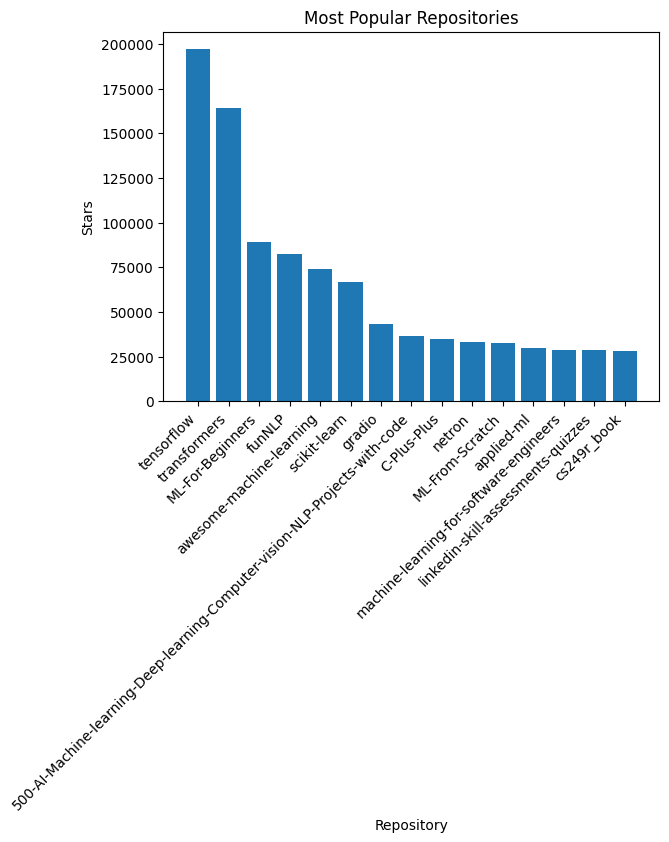

In [139]:
top_repos = df.sort_values('stars', ascending=False).head(15)

plt.bar(top_repos['name'], top_repos['stars'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Repository')
plt.ylabel('Stars')
plt.title('Most Popular Repositories')
plt.show()

Repository Creation Trends Over Time

The repository creation dates are analysed to identify trends in repository creation over time.

The number of repositories created in each year is calculated and displayed using a line chart. This allows changes in repository creation activity to be observed across different years.

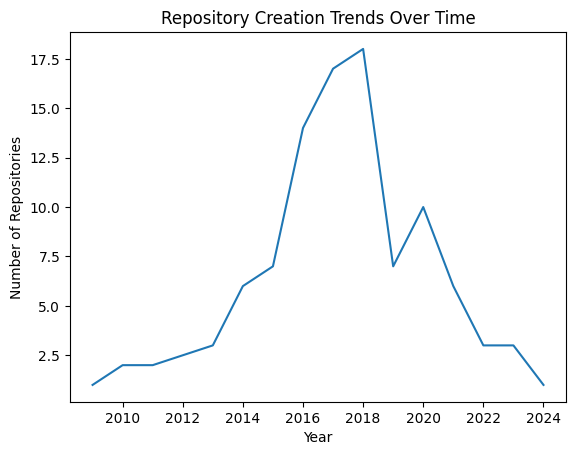

In [140]:
creation_trend = df.groupby(df['created_date'].dt.year).size()

plt.plot(creation_trend.index, creation_trend.values)
plt.xlabel('Year')
plt.ylabel('Number of Repositories')
plt.title('Repository Creation Trends Over Time')
plt.show()

4. Insights and Findings
SQL Analysis Findings

The SQL analysis was used to investigate repository popularity, programming languages, repository statistics, and the distribution of the collected GitHub repositories.

The analysis shows that repository popularity is not evenly distributed. A small number of repositories have significantly more stars than most of the other repositories, indicating that the most popular projects attract much more attention than the majority of repositories.

The SQL queries also provide an overview of the programming languages used in the dataset and allow repository statistics to be compared using aggregate functions such as COUNT() and AVG().

Most Popular Repositories

The bar chart shows the repositories with the highest number of stars.

The repositories are arranged in descending order of stars, making the most popular repositories easy to identify. The chart shows a clear difference between the highest-starred repositories and the rest of the dataset.

This indicates that GitHub repository popularity is highly concentrated among a smaller number of projects.

Repository Creation Trends

The creation trend visualization shows how the number of repositories in the dataset changes across different years.

The number of repositories varies over time rather than remaining constant. The chart shows a period of higher repository creation activity followed by a decline in later years.

This suggests that repository creation activity in the collected dataset was not evenly distributed across the years.

Overall Conclusion

Overall, the analysis shows that the collected GitHub repositories have different levels of popularity and activity.

The SQL analysis provides numerical summaries and comparisons, while the visualizations make the main patterns easier to identify. In particular, the popularity chart demonstrates that a small number of repositories receive substantially more stars, while the creation trend shows that repository creation activity changes over time.

These findings are based on the collected GitHub repository dataset and the SQL and Python analyses performed in this project.

------------------------------------------------------------

1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs to make sure that the data was retrieved correctly and is complete and accurate. Verification can help identify missing values, incorrect data, duplicate records, or API errors before using the data for analysis. In this project, the GitHub API data was checked and the cleaned dataset was verified before further analysis.

2. Why should data analysts document the source of their data?

Data analysts should document the source of their data so that the data can be traced back to its original source. This improves transparency and makes the analysis easier to understand, reproduce, and verify. In this project, the data source is the GitHub API, which should be clearly documented.

3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect results and misleading conclusions. For example, missing repository information can affect calculations such as averages or counts, while inaccurate values can make comparisons between repositories unreliable. Therefore, data should be checked, cleaned, and verified before using it for analysis or making decisions.